# POND MEG Sensor rCCA and Clustering with IM-Biotype

This tutorial pairs **MEG sensor delta power** (149 channels) with **CBCL syndrome total scores** (8 scales) from the POND dataset using regularized CCA. The frequency band is configurable (`FREQ_BAND`).

No demographics are available for this dataset, so preprocessing is **z-score only** (no residualization).

This notebook covers:
1. Data loading and inner join (MEG and clinical have different subject pools)
2. Z-score preprocessing
3. Hyperparameter optimization (regularization grid search)
4. Permutation testing for statistical significance
5. K-means clustering on CCA variates
6. Multi-band comparison across all frequency bands
7. GUI handoff for interactive exploration

In [1]:
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add lib to path so we can import imbiotype
repo_root = Path.cwd().parent  # assumes notebook is in tutorials/
sys.path.insert(0, str(repo_root / "lib"))

from imbiotype import Study
from imbiotype.models.fusion import FusionConfig, CCASettings, ModelSettings
from imbiotype.models.feature_processing import FeatureProcessingConfig
from imbiotype.processing.feature_processor import PreprocessingConfig
from imbiotype.models.clustering import ClusteringConfig, KMeansSettings

print("Imports OK")

Imports OK


## Configuration

Key parameters:
- **Frequency band**: configurable via `FREQ_BAND` (delta, theta, alpha, beta, gamma)
- **5-fold CV**: repeated cross-validation for hyperparameter optimization
- **Lambda grids**: regularization search space for X and Y views
- **Clustering**: evaluate k=2,3,4 on the first N CCA variates

Set `QUICK_TEST_MODE = False` for full replication.

In [2]:
# --- Quick test mode: True = fast (~minutes), False = full replication (~hours) ---
QUICK_TEST_MODE = True

# Frequency band
FREQ_BAND = "delta"  # one of: delta, theta, alpha, beta, gamma

# Paths
data_dir = repo_root / "matlab_adaptation" / "POND_DATA_SCRIPTS"
study_dir = repo_root / "tutorials" / f"pond_meg_{FREQ_BAND}_rcca_study"
meg_path = data_dir / f"MEG_sensor_{FREQ_BAND}.csv"
clinical_path = data_dir / "clinical_CBCL_6-18_syndrome_total_scores.csv"

# Cross-validation
n_cv_folds = 5
n_repeats = 5 if QUICK_TEST_MODE else 1000

# Regularization grids (matching MATLAB reference)
lambda_x = np.logspace(-2, 0, 3 if QUICK_TEST_MODE else 10)
lambda_y = np.logspace(-2, 1, 5 if QUICK_TEST_MODE else 15)

# Permutation testing
n_permutations = 50 if QUICK_TEST_MODE else 1000

# CBCL syndrome total score columns (8 scales)
CBCL_COLUMNS = [
    "Aggressive Behavior:  Total score",
    "Anxious/Depressed:  Total score",
    "Attention Problems:  Total score",
    "Rule-Breaking Behavior:  Total score",
    "Somatic Complaints:  Total score",
    "Social Problems:  Total score",
    "Thought Problems:  Total score",
    "Withdrawn/Depressed:  Total score",
]

N_COMPONENTS = len(CBCL_COLUMNS)  # 8 = min(149 MEG, 8 CBCL)

# Clustering params
N_CLUSTER_MODES = 2   # first N CCA variates to cluster on
CLUSTER_K_RANGE = [2, 3, 4]

print(f"QUICK_TEST_MODE: {QUICK_TEST_MODE}")
print(f"Frequency band: {FREQ_BAND}")
print(f"CV: {n_cv_folds}-fold x {n_repeats} repeats")
print(f"Lambda grid: {len(lambda_x)} x {len(lambda_y)} = {len(lambda_x)*len(lambda_y)} combos")
print(f"Permutations: {n_permutations}")
print(f"Clustering: k={CLUSTER_K_RANGE} on first {N_CLUSTER_MODES} modes")

QUICK_TEST_MODE: True
Frequency band: delta
CV: 5-fold x 5 repeats
Lambda grid: 3 x 5 = 15 combos
Permutations: 50
Clustering: k=[2, 3, 4] on first 2 modes


## What is Regularized CCA?

**Canonical Correlation Analysis (CCA)** finds pairs of linear combinations (canonical variates) that maximize the correlation between two multivariate datasets. Given data matrices X (n x p) and Y (n x q), CCA finds weight vectors **a** and **b** such that:

$$\rho = \text{corr}(X\mathbf{a},\; Y\mathbf{b})$$

is maximized.

When p or q exceeds n (more features than subjects), or when features are highly collinear, the sample covariance matrices become singular. **Regularized CCA** adds a ridge penalty to stabilize estimation:

$$\Sigma_{\text{reg}} = (1 - \lambda)\Sigma + \lambda I$$

where $\lambda \in [0, 1]$ controls the regularization strength. Separate $\lambda_x$ and $\lambda_y$ values are optimized for each data view via cross-validation.

## Optional: Preprocessing from Raw Data

The pre-processed CSVs used by this tutorial were generated from raw POND data through the pipeline below. **If you already have the CSVs, skip to [Create Study & Import Data](#create-study--import-data).**

| Step | Script | Output |
|------|--------|--------|
| 1. Organize raw CTF folders | `POND_reorg_ctf_data.py` | Structured `.ds` directories |
| 2. Preprocess (ICA, artifact rejection) | `POND_preprocessing_final.py` | `*_ica_annot_reconst_meg.fif` |
| 3. Welch PSD → sensor power | `POND_analysis_PSD.py` | `MEG_sensor_{band}.csv` (221 subj x 149 ch) |
| 4. Extract CBCL syndrome scales | `POND_clinical_CBCL.py` | `clinical_CBCL_6-18_syndrome_total_scores.csv` |

Set `RUN_PREPROCESSING = True` and configure paths in the next cell to run the full pipeline. Requires raw POND data, MNE-Python, MEGnet, and autoreject.

In [3]:
# --- Set to True ONLY if you have raw POND data and want to run preprocessing ---
RUN_PREPROCESSING = False

# Raw data paths (edit these if RUN_PREPROCESSING = True)
POND_RAW_PATH = "/path/to/POND-DataUnzipped"          # unzipped POND download
POND_PREPROC_PATH = "/path/to/POND_MEG_preprocessing"  # output for preprocessed files
POND_CLINICAL_FILES_GLOB = "/path/to/POND-DataUnzipped/**/Clinical*"  # clinical CSVs

# Diagnosis folders to process
DIAGNOSIS_FOLDERS = [
    "Imaging_MEG-RestingState_Typically-Developing",
    "Imaging_MEG-RestingState_ASD",
    "Imaging_MEG-RestingState_ADHD",
    "Imaging_MEG-RestingState_OCD",
]

if RUN_PREPROCESSING:
    import mne
    from mne.preprocessing import ICA
    from mne.annotations import _annotations_starts_stops
    import autoreject
    import matplotlib
    matplotlib.use('Agg')  # non-interactive backend for batch processing
    print("Preprocessing imports OK")
else:
    print("RUN_PREPROCESSING = False — skipping to pre-processed CSVs")

RUN_PREPROCESSING = False — skipping to pre-processed CSVs


### Step 1: Organize Raw CTF Folders

Raw POND downloads contain flat file listings. This step reorganizes them into per-subject `.ds` directories expected by MNE-Python's CTF reader.

In [4]:
if RUN_PREPROCESSING:
    import glob, shutil as _shutil

    for diag_folder in DIAGNOSIS_FOLDERS:
        src_dir = os.path.join(POND_RAW_PATH, diag_folder)
        all_meg_files = glob.glob(src_dir + "/*/*")
        # Extract unique subject IDs from file paths
        all_subj_ids = list(dict.fromkeys(
            os.path.basename(f)[6:14] for f in all_meg_files
        ))

        out_dir = os.path.join(POND_PREPROC_PATH, diag_folder)
        os.makedirs(out_dir, exist_ok=True)

        for subj_id in all_subj_ids:
            subj_files = glob.glob(src_dir + f"/*/*{subj_id}*")
            subj_filename = os.path.splitext(os.path.basename(subj_files[0]))[0]
            subj_path = os.path.join(out_dir, subj_filename + ".ds")
            os.makedirs(subj_path, exist_ok=True)

            for megf in subj_files:
                _shutil.copy(megf, os.path.join(subj_path, os.path.basename(megf)))

        print(f"  {diag_folder}: {len(all_subj_ids)} subjects organized")

    print("Step 1 complete: CTF folders organized")

### Step 2: MEG Preprocessing (ICA + Artifact Rejection)

For each subject:
1. **Notch filter** (60 Hz + harmonics) and **bandpass** (1–100 Hz)
2. **ICA** (20 components, extended infomax) → classify with **MEGnet** to identify cardiac, blink, and saccade artifacts
3. **Autoreject** to annotate bad epochs
4. **Head movement annotation** (segments with >10 mm displacement marked as bad)

Output: `*_ica_annot_reconst_meg.fif` per subject.

> **Note**: This step requires the [MEGnet](https://github.com/kylemath/MegNET_2020) classifier installed separately. Adjust `MEGNET_PYTHON` and `MEGNET_SCRIPT` paths below.

In [5]:
if RUN_PREPROCESSING:
    # MEGnet paths (edit these)
    MEGNET_PYTHON = "/path/to/megnet/python"
    MEGNET_SCRIPT = "/path/to/MEGnet/label_ICA_components.py"

    # Collect all .ds files across diagnosis folders
    all_ds_files = []
    for diag_folder in DIAGNOSIS_FOLDERS:
        folder = os.path.join(POND_PREPROC_PATH, diag_folder)
        all_ds_files.extend(
            [f for f in glob.glob(folder + "/*") if f.endswith(".ds")]
        )

    # Find common channels across all recordings
    chs_list = []
    for f in all_ds_files:
        raw = mne.io.read_raw_ctf(f, preload=False).pick_types("mag")
        chs_list.append(set(raw.info["ch_names"]))
    common_chs = sorted(set.intersection(*chs_list))
    # Remove known bad channel
    common_chs = [c for c in common_chs if "MRP21" not in c]
    common_chs_base = [c.split("-")[0] for c in common_chs]
    print(f"Common channels across {len(all_ds_files)} files: {len(common_chs_base)}")

    for idx_f, f in enumerate(all_ds_files):
        print(f"\n[{idx_f+1}/{len(all_ds_files)}] {os.path.basename(f)}")

        raw = mne.io.read_raw_ctf(f, preload=True)
        raw.info.rename_channels({c: c.split("-")[0] for c in raw.info["ch_names"]})

        # Head position for movement annotation
        dev_head_t_ref = raw.info["dev_head_t"]
        chpi_locs = mne.chpi.extract_chpi_locs_ctf(raw)
        head_pos = mne.chpi.compute_head_pos(raw.info, chpi_locs)

        # Select magnetometers + common channels
        raw = raw.pick_types("mag").pick_channels(common_chs_base)

        # Filter
        filtered = raw.copy()
        filtered = filtered.notch_filter([60, 120])
        filtered = filtered.filter(l_freq=1, h_freq=100)

        # ICA (extended infomax, 20 components)
        ica = ICA(
            n_components=20, max_iter="auto", method="infomax",
            random_state=97, fit_params=dict(extended=True),
        )
        ica.fit(filtered, verbose="error")

        # MEGnet artifact classification
        ica_folder = f.replace("_meg.ds", "ICA/")
        os.makedirs(ica_folder, exist_ok=True)

        # Save ICA spatial maps and time series for MEGnet
        arrTimeSeries = ica.get_sources(filtered)[:][0]
        comp_array = np.empty([ica.n_components, 120, 120, 3], dtype=object)
        for c in range(ica.n_components):
            fig = plt.figure(dpi=100, figsize=[1.2, 1.2])
            ax = fig.add_axes([0, 0, 1, 1])
            ica.plot_components(
                show=False, picks=c, axes=ax, extrapolate="head",
                cmap="bwr", res=80, outlines="head", sensors=False,
                contours=0, sphere=0.15, title=""
            )
            fig.set_size_inches(1.2, 1.2)
            import matplotlib as _mpl
            idx_outline = np.where(
                [isinstance(x, _mpl.lines.Line2D) for x in ax.get_children()]
            )[0]
            for i in reversed(idx_outline):
                ax.get_children()[i].remove()
            fig.patch.set_facecolor("0")
            canvas = fig.canvas
            canvas.draw()
            buf = canvas.buffer_rgba()
            plot_array = np.asarray(buf)
            plot_array = np.delete(plot_array, 3, 2)
            comp_array[c] = plot_array
            plt.close(fig)

        full_shape = (*comp_array.shape, *np.shape(comp_array.flat[0]))
        arrSpatialMap = np.vstack(comp_array.flatten()).astype(float).reshape(full_shape)
        np.save(os.path.join(ica_folder, "arrTimeSeries"), arrTimeSeries)
        np.save(os.path.join(ica_folder, "arrSpatialMap"), arrSpatialMap)

        # Run MEGnet classifier
        cmd = f"{MEGNET_PYTHON} {MEGNET_SCRIPT} --input_path {ica_folder} --output_dir {ica_folder} --output_type list"
        cmd_out = os.system(cmd)

        model_exclude = []
        if cmd_out == 0:
            with open(ica_folder + "ICA_component_lables.txt", "r") as fic:
                IClabel = [float(line.strip()) for line in fic if line]
            model_exclude = np.nonzero(IClabel)[0].tolist()
            print(f"  MEGnet: exclude ICs {model_exclude}")

        # Reconstruct signal after removing artifact ICs
        ica.exclude = model_exclude
        reconst = filtered.copy()
        ica.apply(reconst)

        # Autoreject: annotate bad segments
        picks = mne.pick_types(raw.info, meg=True, ref_meg=False)
        reconst.pick(picks)
        epochs = mne.make_fixed_length_epochs(
            reconst, duration=1, preload=True,
            reject_by_annotation=False, proj=False
        )
        ar = autoreject.AutoReject(n_jobs=1, verbose=False)
        ar.fit(epochs)
        _, reject_log = ar.transform(epochs, return_log=True)

        bad_idx = np.nonzero(reject_log.bad_epochs)[0]
        onset = [float(i) for i in bad_idx]
        duration = [1.0] * len(bad_idx)
        annot = mne.Annotations(
            onset=onset, duration=duration,
            description="BAD_segment_AR",
            orig_time=reconst.info["meas_date"]
        )

        # Head movement annotation (>10 mm)
        annotation_movement, _ = mne.preprocessing.annotate_movement(
            raw, head_pos, mean_distance_limit=0.01
        )
        reconst.set_annotations(annot + annotation_movement)

        # Save
        out_path = f.replace("_meg.ds", "_ica_annot_reconst_meg.fif")
        reconst.save(out_path, overwrite=True)
        print(f"  Saved: {os.path.basename(out_path)}")
        plt.close("all")

    print("\nStep 2 complete: all files preprocessed")

### Step 3: Compute Welch PSD → Sensor Power CSVs

Computes **relative power spectral density** (Welch method) for each frequency band:
- **delta**: 1–6 Hz, **theta**: 6–14 Hz, **alpha**: 14–24 Hz, **beta**: 24–59 Hz, **gamma**: 59–45 Hz

For each subject: 2 s epochs → Welch PSD → relative power → dB transform → average within each band. Subjects with >50% rejected data are excluded.

Output: `MEG_sensor_{band}.csv` (one per band, 221 subjects x 149 channels).

In [6]:
if RUN_PREPROCESSING:
    # Collect all preprocessed .fif files
    all_fif_files = []
    for diag_folder in DIAGNOSIS_FOLDERS:
        folder = os.path.join(POND_PREPROC_PATH, diag_folder)
        all_fif_files.extend(
            [f for f in glob.glob(folder + "/*")
             if "_ica_annot_reconst_meg.fif" in f]
        )
    print(f"Found {len(all_fif_files)} preprocessed files")

    # Find channels present in all (or nearly all) datasets
    chs_presence = []
    for f in all_fif_files:
        meg = mne.io.read_raw_fif(f)
        chs_presence.append(
            pd.DataFrame(data=[1] * len(meg.info["ch_names"]),
                         index=meg.info["ch_names"])
        )
    chs_df = pd.concat(chs_presence, axis=1)
    threshold = len(all_fif_files) - 1  # allow 1 missing
    chs_keep = list(chs_df.index[chs_df.sum(axis=1) >= threshold].values)
    print(f"Channels present in >= {threshold} files: {len(chs_keep)}")

    # Frequency band edges (Hz) — indices into the PSD array depend on freq resolution
    BAND_RANGES = {
        "delta": (0, 6), "theta": (6, 14), "alpha": (14, 24),
        "beta": (24, 59), "gamma": (59, None),
    }

    # Initialize DataFrames for each band
    band_dfs = {band: None for band in BAND_RANGES}

    for idx_f, f in enumerate(all_fif_files):
        meg = mne.io.read_raw_fif(f)
        meg = meg.pick_channels(chs_keep)
        subjid = os.path.basename(f)[:14]

        # Skip if > 50% bad data
        onset, ends = _annotations_starts_stops(meg, "Bad")
        bad_count = np.zeros((1, meg.n_times))
        for o, e in zip(onset, ends):
            bad_count[:, o:e] = 1
        perc_reject = bad_count.sum() / meg.n_times
        if perc_reject > 0.5:
            print(f"  [{idx_f+1}] {subjid}: {perc_reject:.0%} bad — SKIPPED")
            continue

        # Epoch and compute PSD
        epochs = mne.make_fixed_length_epochs(
            meg, duration=2, preload=True,
            reject_by_annotation=True, proj=False
        )
        sfreq = int(meg.info["sfreq"])
        spectrum = epochs.compute_psd(
            method="welch", fmin=1, fmax=45,
            n_fft=sfreq * 2, n_per_seg=sfreq * 2,
            n_overlap=sfreq, average="mean"
        )
        psd, freqs = spectrum.get_data(return_freqs=True)
        psd_avg = np.average(psd, axis=0)

        # Relative power in dB
        allspec_power = psd_avg.sum(axis=1)
        psd_rel = 10 * np.log10(psd_avg / allspec_power[:, None])

        # Average within each frequency band
        col_names = ["subject_id"] + spectrum.info["ch_names"]
        for band, (lo, hi) in BAND_RANGES.items():
            lo_idx = np.argmin(np.abs(freqs - lo)) if lo else 0
            hi_idx = np.argmin(np.abs(freqs - hi)) if hi else len(freqs)
            psd_band = np.average(psd_rel[:, lo_idx:hi_idx], axis=1)
            row = [subjid] + list(psd_band)
            if band_dfs[band] is None:
                band_dfs[band] = pd.DataFrame(columns=col_names)
            band_dfs[band].loc[len(band_dfs[band])] = row

        if (idx_f + 1) % 20 == 0 or idx_f == 0:
            print(f"  [{idx_f+1}/{len(all_fif_files)}] {subjid}: OK")

    # Save CSVs
    output_dir = str(data_dir)
    for band, df in band_dfs.items():
        if df is not None:
            out_path = os.path.join(output_dir, f"MEG_sensor_{band}.csv")
            df.to_csv(out_path)
            print(f"Saved {out_path} ({len(df)} subjects)")

    print("\nStep 3 complete: PSD CSVs generated")

### Step 4: Extract CBCL Clinical Data

Extracts CBCL 6–18 syndrome total scores from raw POND clinical CSV files (UTF-16 encoded). Recodes string responses to ordinal values (0/1/2) and saves subscale CSVs.

Output: `clinical_CBCL_6-18_syndrome_total_scores.csv` (572 subjects x 8 syndrome scales + `primary_diagnosis`).

In [7]:
if RUN_PREPROCESSING:
    from functools import reduce

    # Load all clinical CSV files (UTF-16 encoded)
    clinical_files = glob.glob(POND_CLINICAL_FILES_GLOB, recursive=True)
    clinical_files = [c for c in clinical_files if ".csv" in c]
    clinical_dfs = [pd.read_csv(c, encoding="utf-16") for c in clinical_files]
    clinical_main_df = pd.concat(clinical_dfs)
    print(f"Loaded {len(clinical_files)} clinical files, {len(clinical_main_df)} total rows")

    # Filter to CBCL 6-18 forms
    cbcl_forms = [
        "CBCL_AGES_6_TO_18", "CBCL_AGES_6_TO_18_PAGE_A",
        "CBCL_AGES_6_TO_18_PAGE2", "CBCL_AGES_6_TO_18_PAGE_B",
        "CBCL_AGES_6_TO_18_PAGE_C"
    ]
    clinical_CBCL = clinical_main_df.loc[
        clinical_main_df["form_name"].isin(cbcl_forms)
    ]

    # Pivot: one column per question, indexed by subject_id
    dfs = []
    for qnum, question in enumerate(clinical_CBCL["field_name"].unique()):
        q_data = clinical_CBCL.loc[clinical_CBCL["field_name"] == question]
        q_data = q_data.set_index("subject_id")
        title = q_data["field_desc"].values[0]
        if qnum == 0:
            col = pd.DataFrame(
                q_data[["primary_diagnosis", "field_value"]].values,
                columns=["primary_diagnosis", title], index=q_data.index
            )
        else:
            col = pd.DataFrame(
                q_data[["field_value"]].values,
                columns=[title], index=q_data.index
            )
        col = col.loc[~col.index.duplicated(keep="first")]
        dfs.append(col)

    clinical_CBCL_final = pd.concat(dfs, axis=1)

    # Recode string responses to ordinal values
    recode_map = {
        "999": np.nan, "999 - Missing": np.nan,
        "0 - Normal": 0,
        "1 - B (Borderline clinical range)": 1,
        "2 - C (Clinical range)": 2,
        "0 = Not True (as far as you know)": 0,
        "1 = Somewhat or Sometimes True": 1,
        "2 = Very True or Often True": 2,
    }
    for c in range(clinical_CBCL_final.shape[1]):
        col_copy = clinical_CBCL_final.iloc[:, c].copy()
        for old_val, new_val in recode_map.items():
            mask = col_copy == old_val
            if mask.any():
                clinical_CBCL_final.iloc[mask.values, c] = new_val

    # Extract syndrome total scores
    syndrome_cols = [
        "primary_diagnosis",
        "Aggressive Behavior:  Total score",
        "Anxious/Depressed:  Total score",
        "Attention Problems:  Total score",
        "Rule-Breaking Behavior:  Total score",
        "Somatic Complaints:  Total score",
        "Social Problems:  Total score",
        "Thought Problems:  Total score",
        "Withdrawn/Depressed:  Total score",
    ]
    clinical_syndrome = clinical_CBCL_final.loc[:, syndrome_cols]

    # Save
    output_dir = str(data_dir)
    clinical_CBCL_final.to_csv(os.path.join(output_dir, "clinical_CBCL_6-18.csv"))
    clinical_syndrome.to_csv(
        os.path.join(output_dir, "clinical_CBCL_6-18_syndrome_total_scores.csv")
    )
    print(f"Saved clinical CSVs ({len(clinical_syndrome)} subjects)")
    print("\nStep 4 complete: CBCL data extracted")

---

## <a id="create-study--import-data"></a> START HERE — If Using Pre-Processed CSVs

**Skip the preprocessing steps above if you already have:**
- `MEG_sensor_{band}.csv` (MEG sensor power, 221 subjects x 149 channels)
- `clinical_CBCL_6-18_syndrome_total_scores.csv` (8 CBCL syndrome scales, 572 subjects)

These files are in `matlab_adaptation/POND_DATA_SCRIPTS/`.

### Create Study & Import Data

The `Study` class organizes raw data, feature definitions, and analysis results in a structured directory.

In [8]:
# Clean up any previous study directory and create fresh
if study_dir.exists():
    shutil.rmtree(study_dir)

study = Study.create(str(study_dir), f"POND_CBCL_MEG_{FREQ_BAND}_rCCA")

# Import the two CSV files
study.import_dataset(str(meg_path))
study.import_dataset(str(clinical_path))

print(f"Study created at: {study_dir}")

Study created at: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study


## Data Preparation

The MEG and clinical datasets have **different subject pools** (221 MEG vs ~572 clinical). We:
1. Remove the `Unnamed: 0` index column from the MEG CSV
2. Inner join on `subject_id` (keeping only shared subjects)
3. Drop rows with missing CBCL values

We also keep `primary_diagnosis` from the clinical data for downstream cluster visualization.

In [9]:
meg_dataset = f"MEG_sensor_{FREQ_BAND}.csv"
clinical_dataset = "clinical_CBCL_6-18_syndrome_total_scores.csv"

# Remove 'Unnamed: 0' index column from MEG data
study.apply_select_columns_to_dataset(
    dataset_name=meg_dataset,
    remove_columns=["Unnamed: 0"]
)

# Inner join on subject_id — keep clinical columns + primary_diagnosis
clinical_cols_to_keep = ["subject_id", "primary_diagnosis"] + CBCL_COLUMNS
study.apply_join_datasets_to_dataset(
    anchor_dataset_name=meg_dataset,
    anchor_on="subject_id",
    adjoining_dataset_name=clinical_dataset,
    adjoining_on="subject_id",
    adjoining_columns_to_keep=clinical_cols_to_keep,
    how="inner",
    output_filename="combined_data.csv"
)
combined_dataset = "combined_data.csv"

# Read combined data to check
processed_dir = Path(study.study_path) / "processed_data"
df_combined = pd.read_csv(processed_dir / combined_dataset)
print(f"After inner join: {len(df_combined)} subjects")

Removing columns: ['Unnamed: 0']


Successfully saved processed dataset to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/processed_data/MEG_sensor_delta.csv
Successfully joined datasets using 'inner' join. Resulting rows: 189
Successfully saved processed dataset to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/processed_data/combined_data.csv
After inner join: 189 subjects


In [10]:
# Drop rows with any missing CBCL values
imputation_config = {col: {"strategy": "delete_row"} for col in CBCL_COLUMNS}
study.apply_imputation_to_dataset(
    dataset_name=combined_dataset,
    column_configs=imputation_config
)

df_clean = pd.read_csv(processed_dir / combined_dataset)
print(f"After dropping missing: {len(df_clean)} subjects")

Identified 0 rows for deletion based on NaNs in columns: ['Aggressive Behavior:  Total score', 'Anxious/Depressed:  Total score', 'Attention Problems:  Total score', 'Rule-Breaking Behavior:  Total score', 'Somatic Complaints:  Total score', 'Social Problems:  Total score', 'Thought Problems:  Total score', 'Withdrawn/Depressed:  Total score']
No missing values imputed based on the provided configuration and data.
Successfully saved processed dataset to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/processed_data/combined_data.csv
After dropping missing: 189 subjects


## Inspect the Data

In [11]:
meg_cols = [c for c in df_clean.columns if c.startswith("M")]
print(f"MEG data: {len(df_clean)} subjects x {len(meg_cols)} channels")
print(f"  Channels: {meg_cols[0]} ... {meg_cols[-1]}")

print(f"\nCBCL syndrome scales: {len(CBCL_COLUMNS)}")
for col in CBCL_COLUMNS:
    print(f"  - {col}")

print(f"\nDiagnosis distribution: {df_clean['primary_diagnosis'].value_counts().to_dict()}")

# Drop identifiable columns before displaying
df_clean.drop(columns=["subject_id"]).head(3)

## Create Features

We create two feature vectors:
- **meg_features**: 149 MEG channels (prefix `M`)
- **cbcl_features**: 8 CBCL syndrome total scores (explicit column list)

In [12]:
final_dataset = combined_dataset

study.create_feature_simple(
    name="meg_features", dataset=final_dataset,
    pattern="M", pattern_type="prefix"
)

study.create_feature_simple(
    name="cbcl_features", dataset=final_dataset,
    columns=CBCL_COLUMNS
)

n_meg = len([c for c in df_clean.columns if c.startswith("M")])
print(f"meg_features: {n_meg} MEG channels")
print(f"cbcl_features: {len(CBCL_COLUMNS)} CBCL syndrome scales")

meg_features: 149 MEG channels
cbcl_features: 8 CBCL syndrome scales


## Configure Preprocessing

Unlike the EEG tutorial, we have **no demographics** (Age, Sex) for this dataset. Preprocessing is **z-score only** — no residualization needed.

When HPO is enabled, z-scoring is applied **inside each CV fold** to prevent data leakage.

In [13]:
# MEG: z-score only (no residualization)
meg_preproc = PreprocessingConfig(
    standardize={"with_mean": True, "with_std": True}
)

# CBCL: z-score only
cbcl_preproc = PreprocessingConfig(
    standardize={"with_mean": True, "with_std": True}
)

feature_processing_configs = [
    FeatureProcessingConfig(feature_name="meg_features", preprocessing_config=meg_preproc),
    FeatureProcessingConfig(feature_name="cbcl_features", preprocessing_config=cbcl_preproc),
]

print("Preprocessing configured:")
print("  meg_features:    z-score")
print("  cbcl_features:   z-score")

Preprocessing configured:
  meg_features:    z-score
  cbcl_features:   z-score


## Configure CCA Model

Key choices:
- **CCA type**: `"regularized"` with `"covariance"` regularization (MATLAB-style: $(1-\lambda)\Sigma + \lambda I$)
- **HPO**: Grid search over `lambda_x` x `lambda_y`
- **5-fold CV**: repeated cross-validation
- **Components**: 8 (min of 149 MEG channels, 8 CBCL syndrome scales)

In [14]:
cca_settings = CCASettings(
    skip_cca=False,
    x_main_feature_vector_name="meg_features",
    y_main_feature_vector_name="cbcl_features",
    hyperparameter_optimization_enabled=True
)

# Model: regularized CCA with MATLAB-style covariance regularization
cca_settings.model_settings.cca_type = "regularized"
cca_settings.model_settings.regularization_method = "covariance"
cca_settings.model_settings.n_components = N_COMPONENTS

# HPO: repeated CV with lambda grid search
cca_settings.optimization_settings.cv_folds = n_cv_folds
cca_settings.optimization_settings.n_repeats = n_repeats
cca_settings.optimization_settings.regularization_x_values = lambda_x.tolist()
cca_settings.optimization_settings.regularization_y_values = lambda_y.tolist()
cca_settings.optimization_settings.objective_metric = "correlation"
cca_settings.optimization_settings.random_state = 42

print(f"CCA type: regularized (covariance method)")
print(f"Components: {N_COMPONENTS}")
print(f"HPO grid: {len(lambda_x)} x {len(lambda_y)} = {len(lambda_x)*len(lambda_y)} combos")
print(f"CV: {n_cv_folds}-fold x {n_repeats} repeats")

CCA type: regularized (covariance method)
Components: 8
HPO grid: 3 x 5 = 15 combos
CV: 5-fold x 5 repeats


## Configure Statistical Testing

Permutation testing establishes whether canonical correlations exceed chance:

1. **Null distribution**: Shuffle Y (clinical) data while keeping X (MEG) fixed
2. **P-value**: $(\#\{r_{\text{perm}} > r_{\text{observed}}\} + 1) \;/\; (n_{\text{perms}} + 1)$
3. **Bonferroni correction**: Adjusts for testing across 8 canonical modes

In [15]:
# Permutation testing
cca_settings.statistical_testing.enabled = True
cca_settings.statistical_testing.test_type = "shuffle_y"
cca_settings.statistical_testing.n_permutations = n_permutations
cca_settings.statistical_testing.respect_groups = False
cca_settings.statistical_testing.multiple_comparisons_correction = "bonferroni"
cca_settings.statistical_testing.test_statistic = "canonical_correlation"
cca_settings.statistical_testing.test_individual_components = True
cca_settings.statistical_testing.test_aggregate_statistic = False
cca_settings.statistical_testing.alpha = 0.05

# Bootstrap disabled
cca_settings.bootstrap_settings.enabled = False

print(f"Permutations: {n_permutations}")
print(f"Strategy: shuffle Y")
print(f"Correction: Bonferroni across {N_COMPONENTS} modes")

Permutations: 50
Strategy: shuffle Y
Correction: Bonferroni across 8 modes


## Run Analysis

Assembling settings into a `FusionConfig` and running. With `QUICK_TEST_MODE=True` this should finish in a few minutes.

In [16]:
fusion_config = FusionConfig(
    name=f"POND_CBCL_MEG_{FREQ_BAND}_rCCA",
    feature_processing_configs=feature_processing_configs,
    cca_settings=cca_settings
)

print("Running rCCA analysis...")
fusion_run_id = study.run_fusion(fusion_config)
print(f"\nDone! Fusion run ID: {fusion_run_id}")

Running rCCA analysis...
[Fusion] MATLAB-compatible mode: Applying only outside-CV steps before CCA
[Fusion] Applied with_hpo outside-CV steps to 'meg_features': (189, 149) -> (189, 149)
[Fusion] Applied with_hpo outside-CV steps to 'cbcl_features': (189, 8) -> (189, 8)
[Fusion] Preserved column names for 'meg_features': ['MLC11', 'MLC12', 'MLC13']... (n=149)
[Fusion] Preserved column names for 'cbcl_features': ['Aggressive Behavior:  Total score', 'Anxious/Depressed:  Total score', 'Attention Problems:  Total score']... (n=8)
Using unified CCA implementation...
Using new preprocessing architecture...
Creating processing plans with new architecture...
Preparing data for structural loadings...
[Enhanced CCA] Using data with outside-CV steps already applied by fusion.py
[Enhanced CCA] X data shape: (189, 149), Y data shape: (189, 8)
Starting hyperparameter optimization...
Using explicit lambda values: 3 x 5 = 15 combinations
Created hyperparameter grid with 15 combinations (3×5)

MATLAB-

 → 0.2224
  Testing λx=0.0100, λy=0.0562

 → 0.2641
  Testing λx=0.0100, λy=0.3162 → 0.2624
  Testing λx=0.0100, λy=1.7783 → 0.2790
  Testing λx=0.0100, λy=10.0000 → 0.2773
  Testing λx=0.1000, λy=0.0100

 → 0.1582
  Testing λx=0.1000, λy=0.0562 → 0.1826
  Testing λx=0.1000, λy=0.3162 → 0.2276
  Testing λx=0.1000, λy=1.7783

 → 0.3309
  Testing λx=0.1000, λy=10.0000 → 0.3227
  Testing λx=1.0000, λy=0.0100 → 0.0055
  Testing λx=1.0000, λy=0.0562 → 0.0021
  Testing λx=1.0000, λy=0.3162 → -0.0187
  Testing λx=1.0000, λy=1.7783

...

  Completed 10/50 permutations


  Completed 20/50 permutations


  Completed 30/50 permutations


  Completed 40/50 permutations


  Completed 50/50 permutations
Saved meg_features PCA components to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/fusion/20260227_190051/PCA/meg_features_pca_components.csv
Saved cbcl_features PCA components to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/fusion/20260227_190051/PCA/cbcl_features_pca_components.csv
Saved canonical correlations to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/fusion/20260227_190051/cca_steps/canonical_correlations.csv
Saved meg_features structural loadings to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study/fusion/20260227_190051/cca_steps/meg_features_structural_loadings.csv
Saved meg_features structural loadings p-values to: /Us

## Results

The results include:
- **Canonical correlations**: Strength of each canonical mode
- **P-values**: Permutation-based significance (uncorrected and Bonferroni-corrected)
- **Significant modes**: Modes surviving correction at $\alpha = 0.05$

In [17]:
study.print_fusion_results(fusion_run_id)


 Metrics:
  explained_variance: 0.000
  correlation: 0.495

 CCA Results:
Canonical correlations: ['0.651', '0.598', '0.538', '0.516', '0.496', '0.449', '0.384', '0.330']

 Statistical Testing Results:

 Individual Component Tests:
  Correction method: bonferroni
  Alpha level: 0.05
  Component 1: p=0.0196, p_corr=0.1569 
  Component 2: p=0.0588, p_corr=0.4706 
  Component 3: p=0.4118, p_corr=1.0000 
  Component 4: p=0.2157, p_corr=1.0000 
  Component 5: p=0.1961, p_corr=1.0000 
  Component 6: p=0.6078, p_corr=1.0000 
  Component 7: p=1.0000, p_corr=1.0000 
  Component 8: p=1.0000, p_corr=1.0000 

 Aggregate Test:
  Log-likelihood test: p=0.1765 

 Permutations performed: 50
*** = Significant at α = 0.05


Plotting scatter of CCA variates for top 3 modes...


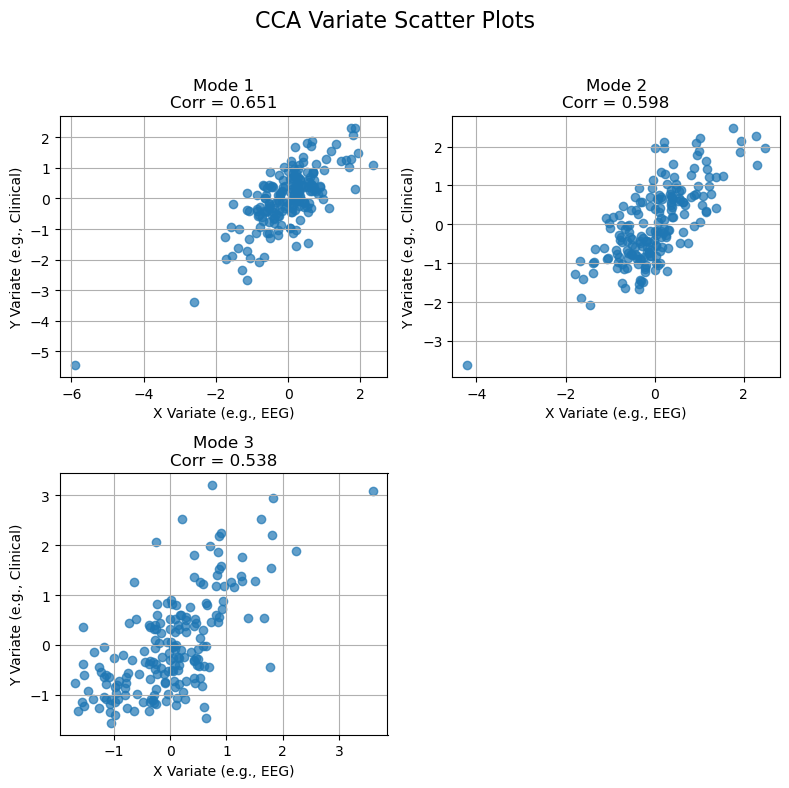

Plotting Y-weights (e.g., clinical features) for top 3 modes...


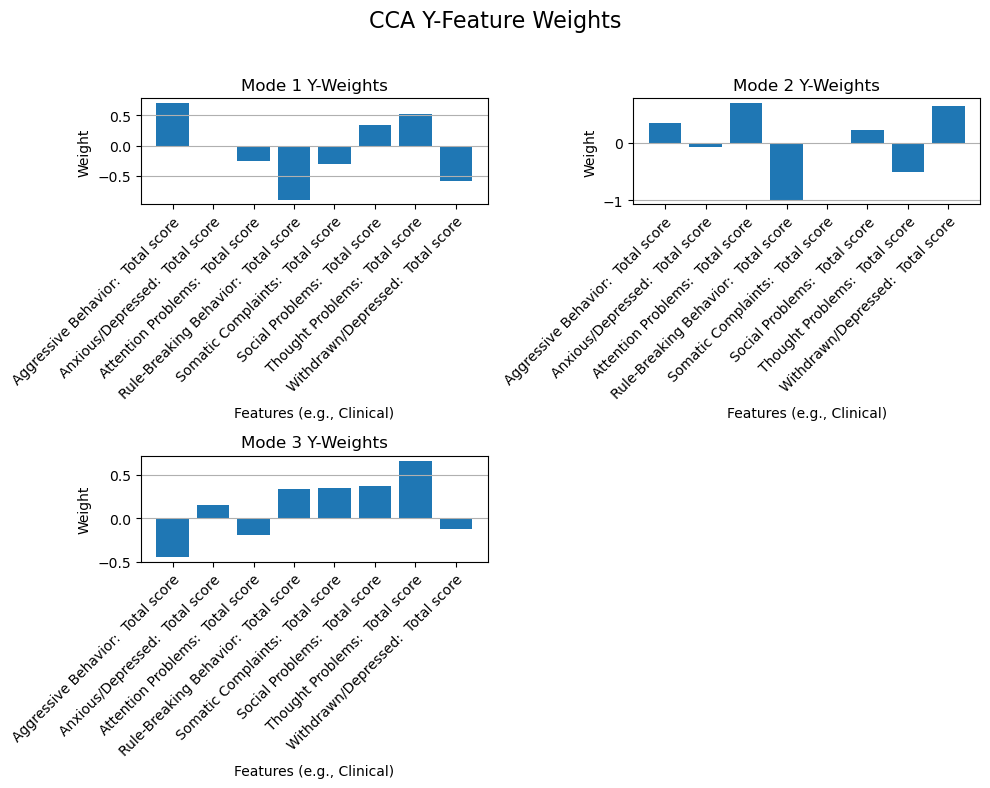

Plotting X-weights (e.g., EEG features) for top 3 modes...


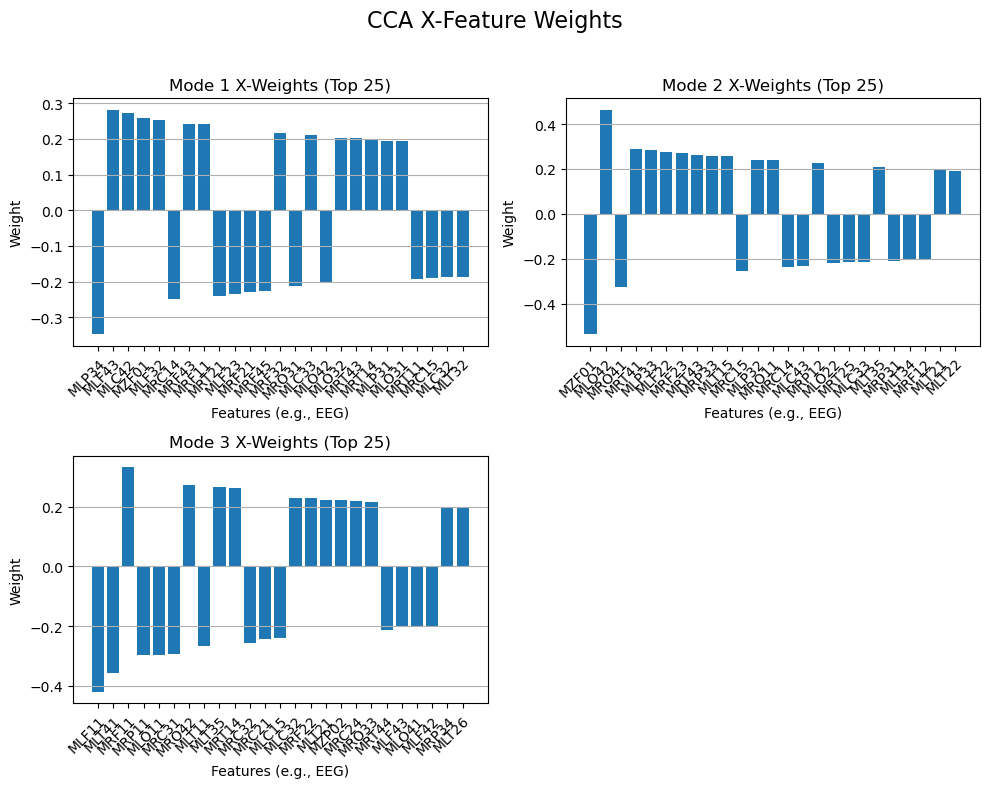

In [18]:
study.plot_cca_results(fusion_run_id, max_modes_to_plot=3)
plt.show()

## Clustering on CCA Variates

We cluster subjects based on their canonical variates (X + Y) from the first `N_CLUSTER_MODES` modes. This reveals subgroups (biotypes) that differ in their MEG-clinical covariation patterns.

Steps:
1. Load the `clustering_input.npz` saved by the fusion run
2. Select first N modes of X and Y variates → concatenate
3. Swap into npz, run k-means for each k, restore original

In [19]:
# Load full clustering input and select variates
fusion_dir = Path(study.study_path) / "fusion" / fusion_run_id
npz_path = fusion_dir / "clustering_input.npz"
backup_path = fusion_dir / "clustering_input_full.npz"

original = dict(np.load(npz_path, allow_pickle=True))
x_var = original["cca_x_transformed"][:, :N_CLUSTER_MODES]
y_var = original["cca_y_transformed"][:, :N_CLUSTER_MODES]
selected = np.hstack([x_var, y_var])  # (n_subjects, N_CLUSTER_MODES*2)

print(f"Clustering data: {selected.shape[0]} subjects x {selected.shape[1]} features")
print(f"  (X variates modes 1-{N_CLUSTER_MODES} + Y variates modes 1-{N_CLUSTER_MODES})")

# Backup original npz, save trimmed version for clustering API
shutil.copy2(npz_path, backup_path)
trimmed = {
    "feature_data": np.array([selected], dtype=object),
    "feature_names": np.array([f"cca_xy_modes_1-{N_CLUSTER_MODES}"]),
    "feature_types": np.array(["cca"]),
}
np.savez(npz_path, **trimmed)
print("Saved trimmed npz (backup at clustering_input_full.npz)")

Clustering data: 189 subjects x 4 features
  (X variates modes 1-2 + Y variates modes 1-2)


Saved trimmed npz (backup at clustering_input_full.npz)


### Evaluate k Values

In [20]:
best_k = None
best_sil = -1
best_run_id = None
clustering_results_all = {}

print(f"Evaluating k = {CLUSTER_K_RANGE}...")

for k in CLUSTER_K_RANGE:
    config = ClusteringConfig(
        name=f"kmeans_k{k}",
        method="kmeans",
        kmeans_settings=KMeansSettings(
            n_clusters=k, init="k-means++", n_init=10,
            max_iter=300, random_state=42
        ),
        fusion_run_id=fusion_run_id
    )
    run_id = study.run_clustering(config, fusion_run_id)
    results = study.load_clustering_results(run_id)
    cr = results["clustering_results"][f"kmeans_k{k}"]
    sil = cr["metrics"]["silhouette"]
    ch = cr["metrics"]["calinski_harabasz"]
    labels = np.array(cr["labels"])
    sizes = np.bincount(labels)
    print(f"  k={k}: silhouette={sil:.3f}, calinski-harabasz={ch:.1f}, sizes={list(sizes)}")

    clustering_results_all[k] = {"run_id": run_id, "labels": labels, "sil": sil}

    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_run_id = run_id

print(f"\nBest k = {best_k} (silhouette = {best_sil:.3f})")

Evaluating k = [2, 3, 4]...

Processing clustering configuration: kmeans_k2
No feature processing configurations found, using raw data


  k=2: silhouette=0.294, calinski-harabasz=74.8, sizes=[108, 81]

Processing clustering configuration: kmeans_k3
No feature processing configurations found, using raw data
  k=3: silhouette=0.314, calinski-harabasz=73.5, sizes=[99, 73, 17]

Processing clustering configuration: kmeans_k4
No feature processing configurations found, using raw data
  k=4: silhouette=0.237, calinski-harabasz=74.3, sizes=[69, 56, 1, 63]

Best k = 3 (silhouette = 0.314)


In [21]:
# Print best clustering results and restore original npz
try:
    study.print_clustering_results(best_run_id)
finally:
    # Always restore original npz so the study remains usable
    shutil.copy2(backup_path, npz_path)
    backup_path.unlink()
    print("Restored original clustering_input.npz")


Clustering Results:
--------------------------------------------------
Number of samples: 189
Number of features: 4

kmeans_k3:
Number of clusters: 3
Metrics:
  silhouette: 0.3137
  calinski_harabasz: 73.4855
  davies_bouldin: 1.0819

Feature Information:
cca_xy_modes_1-2 (cca)
--------------------------------------------------
Restored original clustering_input.npz


## Visualize Clusters

Scatter plots of subjects in CCA variate space:
1. Colored by **cluster assignment** (best k)
2. Colored by **primary diagnosis** (ADHD/ASD/TD/OCD) for comparison

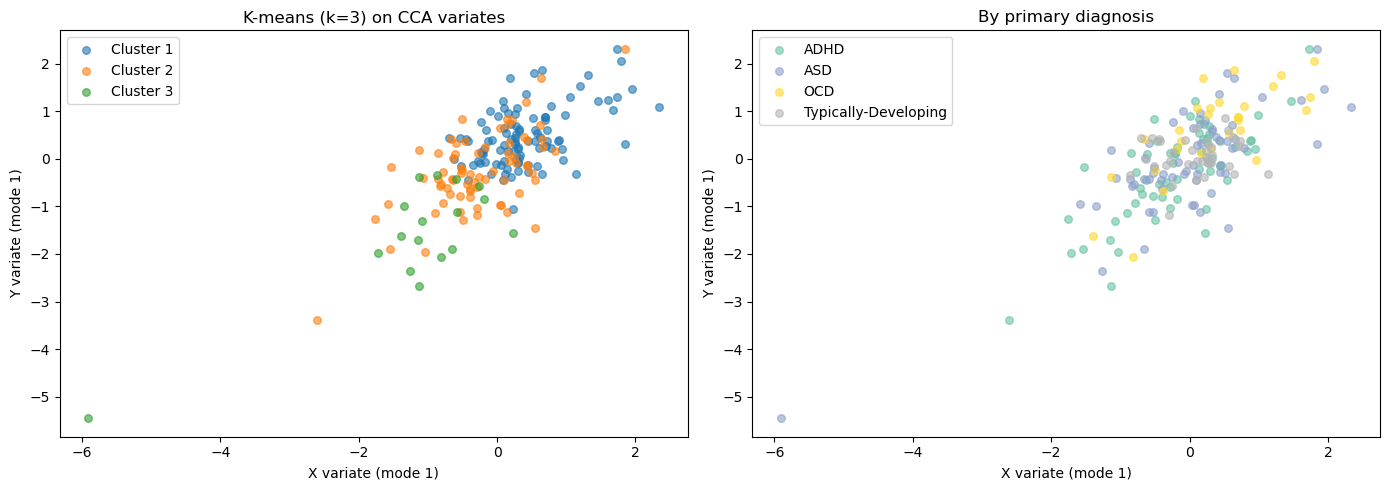

In [22]:
best_labels = clustering_results_all[best_k]["labels"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Colored by cluster
ax = axes[0]
for c in range(best_k):
    mask = best_labels == c
    ax.scatter(x_var[mask, 0], y_var[mask, 0], label=f"Cluster {c+1}", alpha=0.6, s=30)
ax.set_xlabel("X variate (mode 1)")
ax.set_ylabel("Y variate (mode 1)")
ax.set_title(f"K-means (k={best_k}) on CCA variates")
ax.legend()

# Plot 2: Colored by diagnosis
ax = axes[1]
diagnoses = df_clean["primary_diagnosis"].values
unique_dx = sorted(df_clean["primary_diagnosis"].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_dx)))
for dx, color in zip(unique_dx, colors):
    mask = diagnoses == dx
    ax.scatter(x_var[mask, 0], y_var[mask, 0], label=dx, alpha=0.6, s=30, color=color)
ax.set_xlabel("X variate (mode 1)")
ax.set_ylabel("Y variate (mode 1)")
ax.set_title("By primary diagnosis")
ax.legend()

plt.tight_layout()
plt.show()

## Summary & GUI Handoff

This tutorial demonstrated a complete rCCA + clustering workflow:
1. Loaded MEG sensor power (149 ch) and CBCL syndrome total scores (8 scales)
2. Inner joined datasets (different subject pools)
3. Z-score preprocessing (no demographics available)
4. Optimized regularization via 5-fold nested CV grid search
5. Tested significance with permutations + Bonferroni correction
6. Clustered on first 2 CCA variates with k-means

**To change frequency band**: Set `FREQ_BAND = "theta"` (or alpha, beta, gamma) in the Configuration cell and rerun.

**For full replication**: Set `QUICK_TEST_MODE = False` (`n_repeats=1000`, `n_permutations=1000`).

**Open in GUI**: The study can be loaded in the IM-Biotype GUI for interactive exploration (GUI to be released separately upon publication).

In [23]:
print(f"Study path: {study.study_path}")
print(f"\nTo open in GUI:")
print(f"  cd {repo_root}")
print(f"  python main.py")
print(f"  File → Open Study → select: {study.study_path}")

Study path: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study

To open in GUI:
  cd /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA
  python main.py
  File → Open Study → select: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/pond_meg_delta_rcca_study
